## Import, Load and Inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


## Data Cleaning

In [5]:
df['date'] = pd.to_datetime("01-"+df['month'].astype(str)+"-"+df['year'].astype(str))
df.set_index('date', inplace=True)

In [6]:
df.head()

,year,month,passengers
date,,,
1949-01-01,1949,Jan,112
1949-02-01,1949,Feb,118
1949-03-01,1949,Mar,132
1949-04-01,1949,Apr,129
1949-05-01,1949,May,121


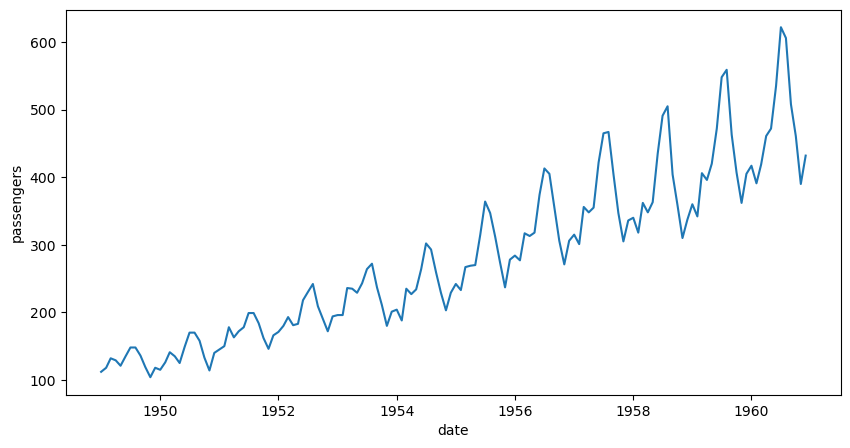

In [7]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x=df.index, y=df.passengers)
plt.show()

## Making the Data Stationary

### shift by 12

In [8]:
df['roll_mean_by_12'] = df.passengers.rolling(window=12).mean() 
df['roll_std_by_12'] = df.passengers.rolling(window=12).std() 

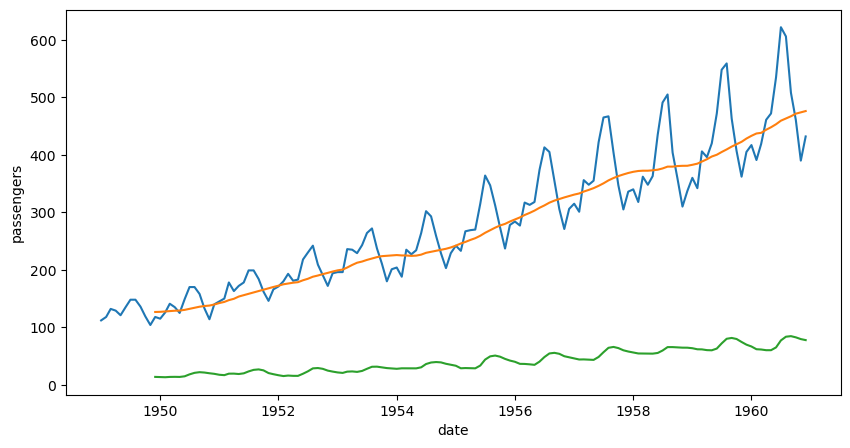

In [9]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x=df.index, y=df.passengers)
sns.lineplot(data=df, x=df.index, y=df.roll_mean_by_12)
sns.lineplot(data=df, x=df.index, y=df.roll_std_by_12)
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

adfTest = adfuller(df['passengers'], autolag='AIC')

In [11]:
adfTest

(np.float64(0.8153688792060472),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.6929308390189))

In [12]:
stats = pd.Series(adfTest[0:4], index=['Test Statistic', 'p-value', '#lags used', 'no. of observation used'])
stats

Test Statistic               0.815369
p-value                      0.991880
#lags used                  13.000000
no. of observation used    130.000000
dtype: float64

In [13]:
for key, values in adfTest[4].items():
    print(f"criticality {key} : {values}")

criticality 1% : -3.4816817173418295
criticality 5% : -2.8840418343195267
criticality 10% : -2.578770059171598


In [14]:
## Test Statistic is not less than the criticality so our data is not stationary

In [15]:
def test_stationarity(dataFrame, var):
    ## Rolling statistics
    dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()

    ## Augmented Dickey-Fuller Test
    adfTest = adfuller(dataFrame[var], autolag='AIC')
    stats = pd.Series(adfTest[0:4], index=['Test Statistic', 'p-value', '#lags used', 'no. of observation used'])
    print(stats)

    ## Critical values
    for key, value in adfTest[4].items():
        print(f'Critical Value ({key}) : {value}')

    ## Plot original series, rolling mean, and rolling std
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=dataFrame, x=dataFrame.index, y=var, label='Original')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollMean', label='Rolling Mean')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollStd', label='Rolling Std')
    plt.title('Rolling Mean & Rolling Standard Deviation')
    plt.legend()
    plt.show()

### shift by 1

In [16]:
air_df = df[['passengers']]
air_df.head()

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [17]:
## time Shift

air_df['shift'] = air_df.passengers.shift()
air_df['shiftDiff'] = air_df.passengers - air_df['shift']
air_df.head()

,passengers,shift,shiftDiff
date,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,112.0,6.0
1949-03-01,132,118.0,14.0
1949-04-01,129,132.0,-3.0
1949-05-01,121,129.0,-8.0


Test Statistic              -2.829267
p-value                      0.054213
#lags used                  12.000000
no. of observation used    130.000000
dtype: float64
Critical Value (1%) : -3.4816817173418295
Critical Value (5%) : -2.8840418343195267
Critical Value (10%) : -2.578770059171598


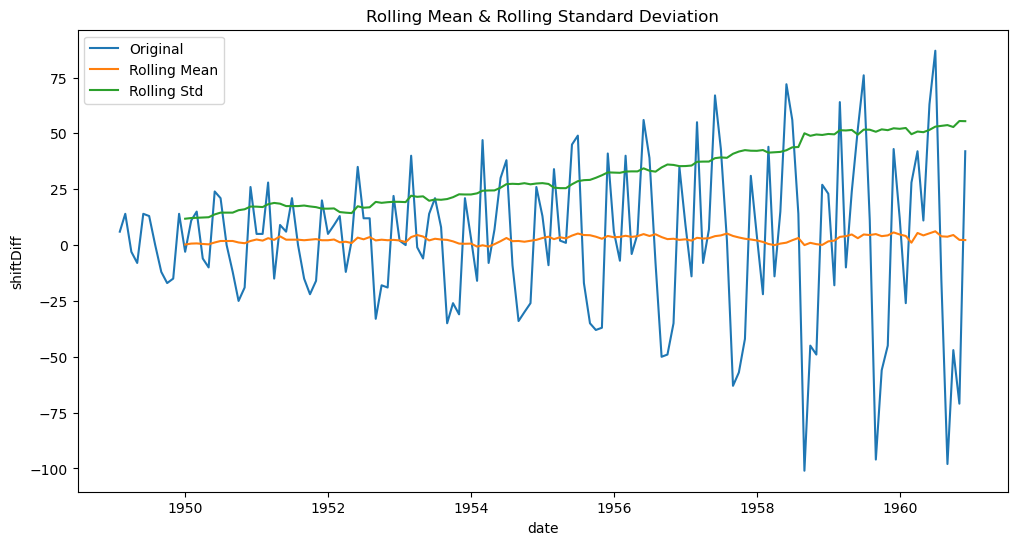

In [18]:
test_stationarity(air_df.dropna(), 'shiftDiff')

### log method

In [19]:
log_df = df[['passengers']]
log_df['log'] = np.log(log_df['passengers'])
log_df.head()

,passengers,log
date,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791


Test Statistic              -1.717017
p-value                      0.422367
#lags used                  13.000000
no. of observation used    130.000000
dtype: float64
Critical Value (1%) : -3.4816817173418295
Critical Value (5%) : -2.8840418343195267
Critical Value (10%) : -2.578770059171598


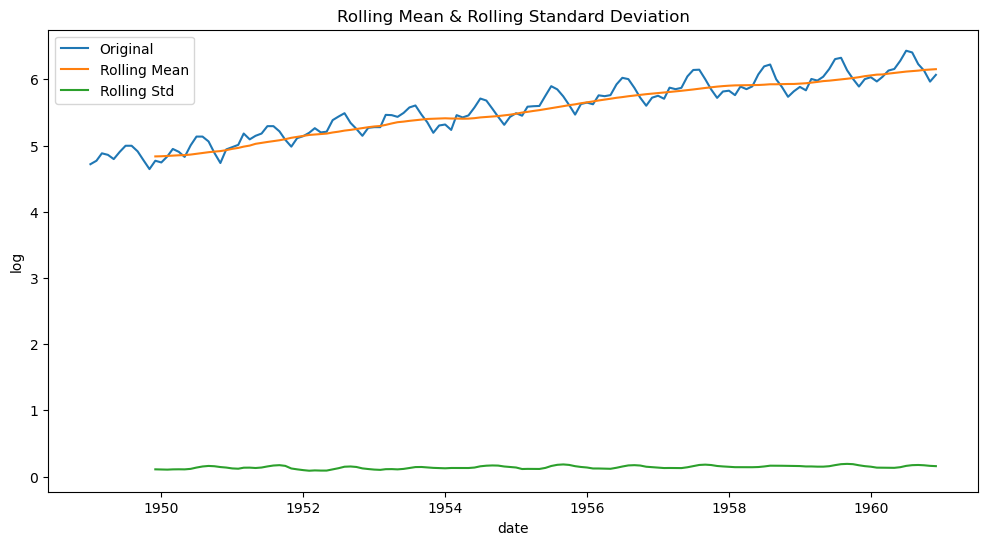

In [20]:
test_stationarity(log_df, 'log')

### sqrt method

In [21]:
sqrt_df = df[['passengers']]
sqrt_df['sqrt'] = np.sqrt(sqrt_df['passengers'])
sqrt_df.head()

,passengers,sqrt
date,,
1949-01-01,112,10.583005
1949-02-01,118,10.862780
1949-03-01,132,11.489125
1949-04-01,129,11.357817
1949-05-01,121,11.000000


Test Statistic              -0.345854
p-value                      0.918754
#lags used                  13.000000
no. of observation used    130.000000
dtype: float64
Critical Value (1%) : -3.4816817173418295
Critical Value (5%) : -2.8840418343195267
Critical Value (10%) : -2.578770059171598


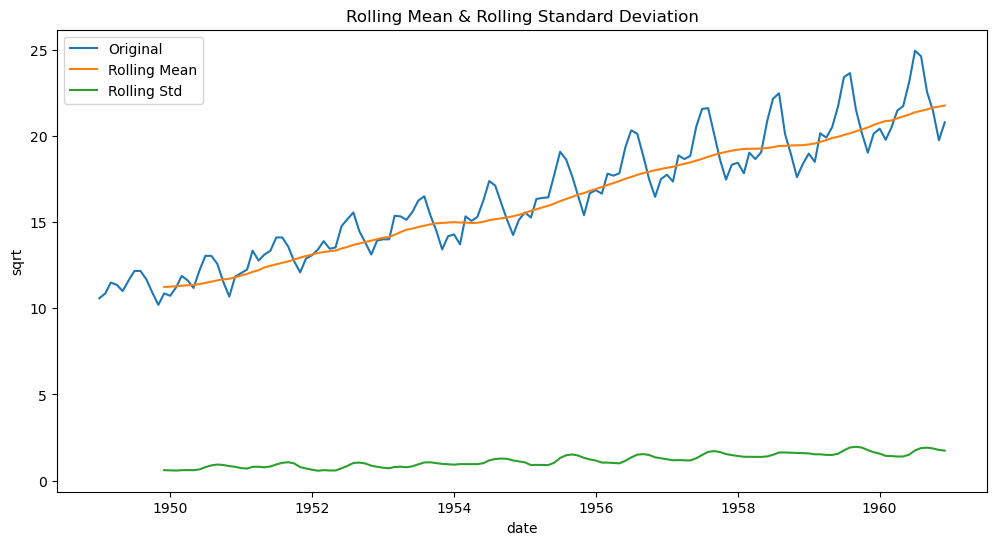

In [22]:
test_stationarity(sqrt_df, 'sqrt')

### cbrt method

In [23]:
cbrt_df = df[['passengers']]
cbrt_df['cbrt'] = np.cbrt(cbrt_df['passengers'])
cbrt_df.head()

,passengers,cbrt
date,,
1949-01-01,112,4.820285
1949-02-01,118,4.904868
1949-03-01,132,5.091643
1949-04-01,129,5.052774
1949-05-01,121,4.946087


Test Statistic              -0.810035
p-value                      0.816157
#lags used                  13.000000
no. of observation used    130.000000
dtype: float64
Critical Value (1%) : -3.4816817173418295
Critical Value (5%) : -2.8840418343195267
Critical Value (10%) : -2.578770059171598


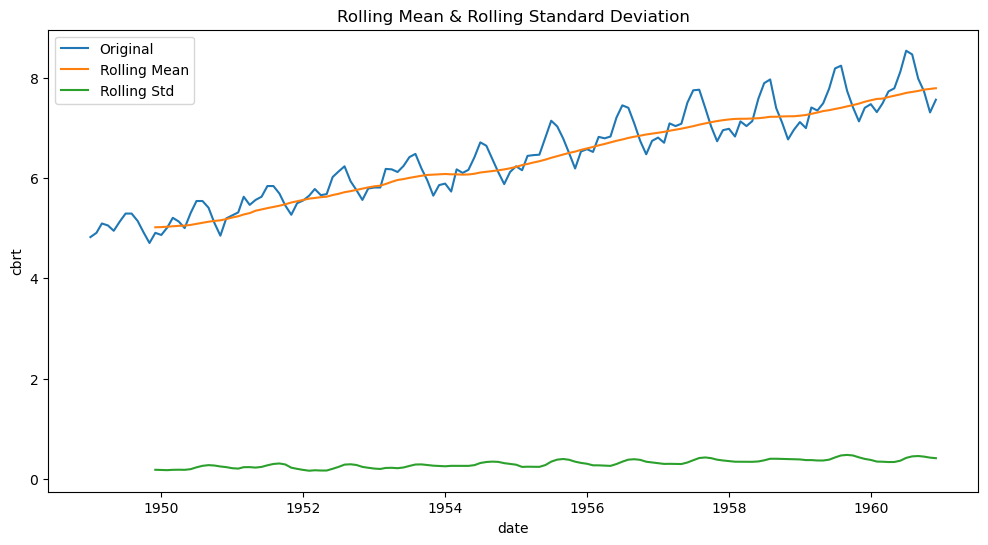

In [24]:
test_stationarity(cbrt_df, 'cbrt')

### log + sqrt + shift

In [25]:
log_df2 = log_df[['passengers', 'log']]
log_df2['log_sqrt'] = np.sqrt(log_df2['log'])
log_df2['log_shift'] = log_df2['log_sqrt'] - log_df2['log_sqrt'].shift()
log_df2.head()

,passengers,log,log_sqrt,log_shift
date,,,,
1949-01-01,112,4.718499,2.172211,NaN
1949-02-01,118,4.770685,2.184190,0.011979
1949-03-01,132,4.882802,2.209706,0.025517
1949-04-01,129,4.859812,2.204498,-0.005208
1949-05-01,121,4.795791,2.189929,-0.014569


Test Statistic              -2.611019
p-value                      0.090741
#lags used                  14.000000
no. of observation used    128.000000
dtype: float64
Critical Value (1%) : -3.4825006939887997
Critical Value (5%) : -2.884397984161377
Critical Value (10%) : -2.578960197753906


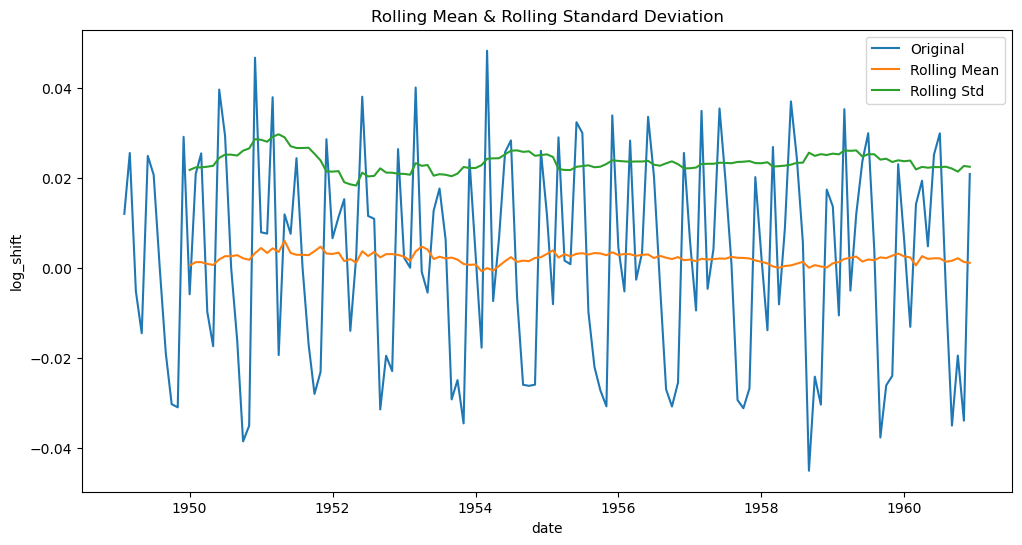

In [26]:
test_stationarity(log_df2.dropna(), 'log_shift')

## Arima Model 

In [27]:
airP = df[['passengers']].copy(deep=True)
airP.head()

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [28]:
airP['firstDiff'] = airP['passengers'].diff()
airP['Diff12'] = airP['passengers'].diff(12)

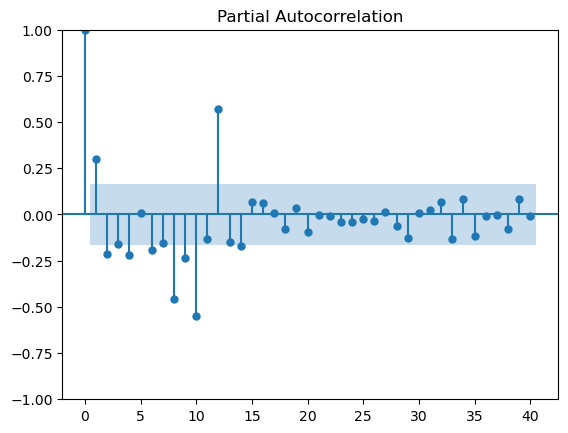

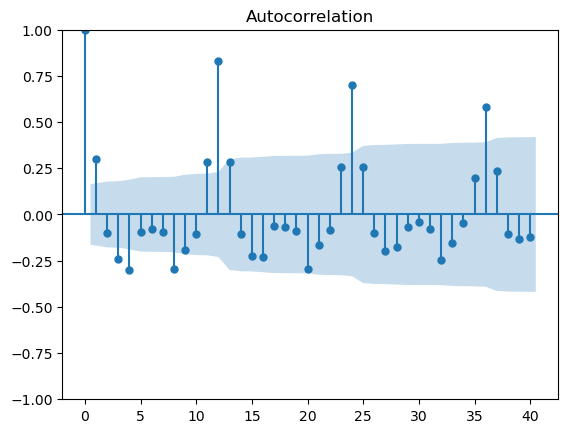

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_pacf(airP['firstDiff'].dropna(), lags=40);
plot_acf(airP['firstDiff'].dropna(), lags=40);

In [30]:
## train test split

train = airP[:round(len(airP)*70/100)]
test = airP[round(len(airP)*70/100):]
print(train.tail())
print()
print(test.head())

            passengers  firstDiff  Diff12
date                                     
1957-01-01         315        9.0    31.0
1957-02-01         301      -14.0    24.0
1957-03-01         356       55.0    39.0
1957-04-01         348       -8.0    35.0
1957-05-01         355        7.0    37.0

            passengers  firstDiff  Diff12
date                                     
1957-06-01         422       67.0    48.0
1957-07-01         465       43.0    52.0
1957-08-01         467        2.0    62.0
1957-09-01         404      -63.0    49.0
1957-10-01         347      -57.0    41.0


In [31]:
## p=1, q=3, d=1

In [32]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(airP['passengers'], order=(1,1,3))
arima_model_fit = arima_model.fit()
Arima_prediction = arima_model_fit.predict(start=test.index[0], end=test.index[-1])

p:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
p:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
p:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [33]:
test['Arima_pred'] = Arima_prediction
test.tail()

,passengers,firstDiff,Diff12,Arima_pred
date,,,,
1960-08-01,606,-16.0,47.0,614.342958
1960-09-01,508,-98.0,45.0,559.456243
1960-10-01,461,-47.0,54.0,465.052543
1960-11-01,390,-71.0,28.0,458.630824
1960-12-01,432,42.0,27.0,380.696414


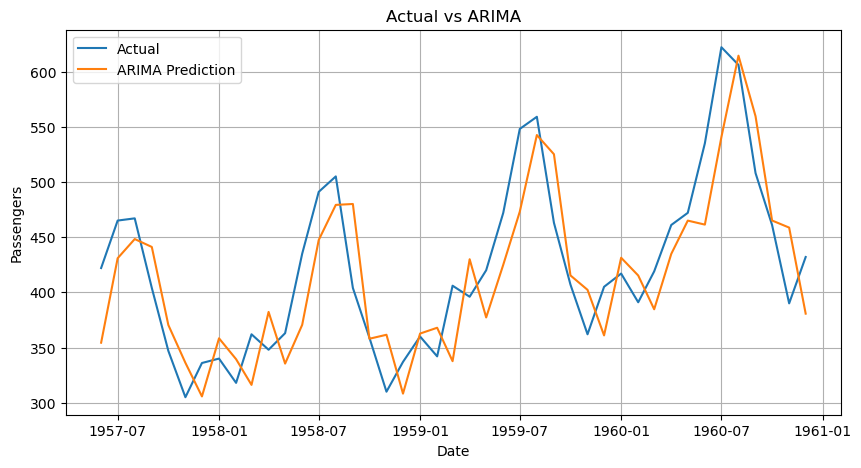

In [34]:
plt.figure(figsize=(10,5))
sns.lineplot(data=test, x=test.index, y='passengers', label='Actual')
sns.lineplot(data=test, x=test.index, y='Arima_pred', label='ARIMA Prediction') 
plt.title("Actual vs ARIMA")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
from sklearn.metrics import mean_squared_error

np.sqrt(mean_squared_error(test['passengers'], Arima_prediction))

np.float64(42.9892315421778)

## Sarimax Model

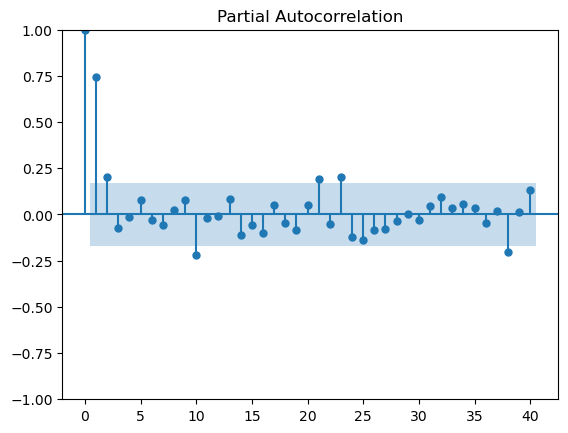

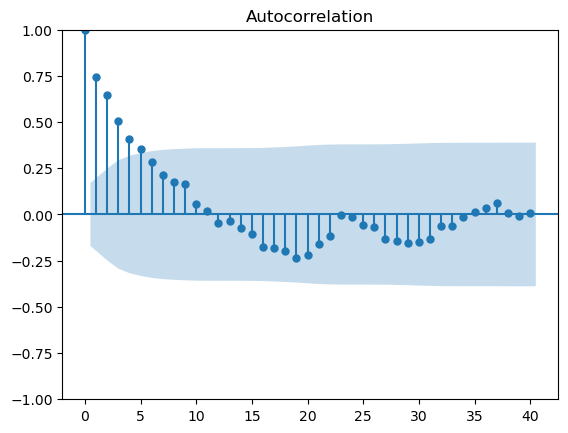

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_pacf(airP['Diff12'].dropna(), lags=40);
plot_acf(airP['Diff12'].dropna(), lags=40);

In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(train['passengers'], order=(1,1,1), seasonal_order=(1, 1, 0, 12))
sarimax_model_fit = sarimax_model.fit()

p:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
p:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [38]:
Sarimax_prediction = sarimax_model_fit.predict(start=test.index[0], end=test.index[-1])
test['Sarimax_pred'] = Sarimax_prediction

In [39]:
test.tail()

,passengers,firstDiff,Diff12,Arima_pred,Sarimax_pred
date,,,,,
1960-08-01,606,-16.0,47.0,614.342958,553.602279
1960-09-01,508,-98.0,45.0,559.456243,506.495384
1960-10-01,461,-47.0,54.0,465.052543,459.228262
1960-11-01,390,-71.0,28.0,458.630824,423.986023
1960-12-01,432,42.0,27.0,380.696414,459.963910


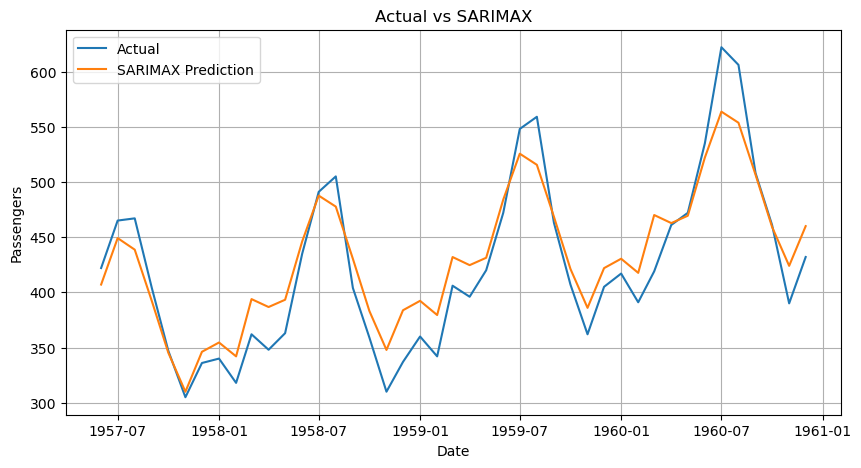

In [40]:
plt.figure(figsize=(10,5))
sns.lineplot(data=test, x=test.index, y='passengers', label='Actual')
sns.lineplot(data=test, x=test.index, y='Sarimax_pred', label='SARIMAX Prediction') 
plt.title("Actual vs SARIMAX")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
from sklearn.metrics import mean_squared_error

np.sqrt(mean_squared_error(test['passengers'], Sarimax_prediction))

np.float64(26.85378630857365)

## Future Prediction

In [42]:
airP.tail()

,passengers,firstDiff,Diff12
date,,,
1960-08-01,606,-16.0,47.0
1960-09-01,508,-98.0,45.0
1960-10-01,461,-47.0,54.0
1960-11-01,390,-71.0,28.0
1960-12-01,432,42.0,27.0


In [43]:
futureDate = pd.DataFrame(pd.date_range(start='1961-01-01	', end='1965-12-01', freq='MS'), columns=['dates'])
futureDate.set_index('dates', inplace=True)

In [44]:
futureDate.head()

""
dates
1961-01-01
1961-02-01
1961-03-01
1961-04-01
1961-05-01


In [46]:
futurePrediction = sarimax_model_fit.predict(start=futureDate.index[0], end=futureDate.index[-1])

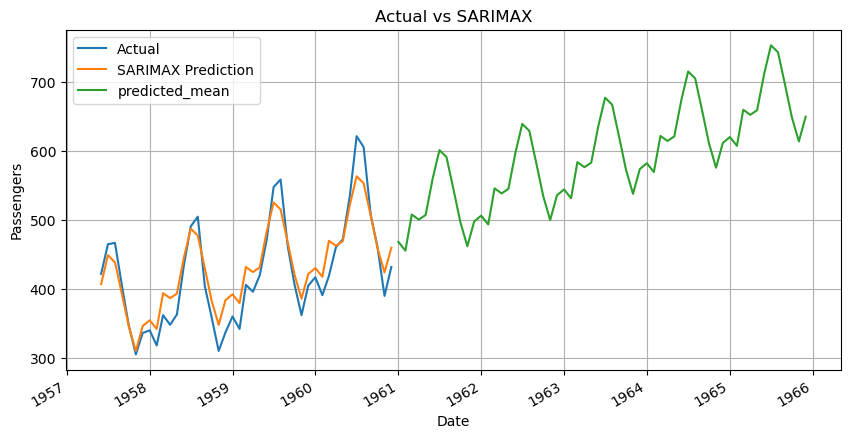

In [47]:
plt.figure(figsize=(10,5))
sns.lineplot(data=test, x=test.index, y='passengers', label='Actual')
sns.lineplot(data=test, x=test.index, y='Sarimax_pred', label='SARIMAX Prediction') 
futurePrediction.plot()
plt.title("Actual vs SARIMAX")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()